# HW3: Extending the Explorer Agents for the Underwater Caldera Using Deep and Pre-Trained Models

<p align="center">
  <img src="../images/caldera-mission-realistic-lighter.png"
       alt="Underwater Caldera exploration mission"
       width="400">
</p>

In HW2, we approached the Caldera exploration problem using active learning, model-based planning, and tabular reinforcement learning. These methods allowed us to compare different ways of making complex decisions under limited information, energy constraints, and partial observability. However, their representations and decision rules were largely handcrafted or tabular, making them difficult to scale to larger and more complex environments.


In this assignment, we extend the explorer agents using deep-learning methods and pre-trained models. Instead of representing states and action values explicitly in a table, we incorporate data-driven methods and neural networks to learn useful representations and decision functions from data. 

Our focus in this assignment will be on active learning and its use in the exploration task. Throughout the assignment, we will compare a data-driven approach with the methods developed in HW2 and examine the trade-offs between learning from data and relying on domain-knowledge-based representations.



For this assignment, we use the extended Caldera environment from HW2, which can be initialized with a set of pits or with an externally supplied depth-map array.


## General Guidelines

While we provide the complete framework for this assignment, the only files you will submit are:

- `to_implement.py` &mdash; where you implement the coding assignment 
- `answers.py` &mdash; where you answer the theoretical questions.

⚠️ **Warning**: these are the only files that will be examined &mdash; any changes you make to other files will be ignored by the grader.

# Setup

The setup is the same as we did for HW2, with the same four reference environments that we will use for all sanity checks and visual tests in this notebook.


In [13]:
%load_ext autoreload
%autoreload 2

import io
import unittest

import matplotlib
import matplotlib.pyplot as plt

import mediapy as media
import numpy as np
from PIL import Image
from tqdm.auto import tqdm
from IPython.display import Markdown

from caldera_env import (
    CalderaEnv, DEFAULT_PIT_PARAMS, DEFAULT_PIT_WEIGHTS, ACTION_NAMES,
    MOVE_NORTH, MOVE_SOUTH, MOVE_EAST, MOVE_WEST, SAMPLE, NO_OP,
)
from explorer import ALExplorer, PlanningExplorer, RLExplorer, OBJECTIVES
import answers
import to_implement as ti

np.random.seed(0)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Render & rollout helpers

Two small helpers let us turn the existing `env.visualize(...)` figure into video frames and run an agent for one episode while capturing a frame at every step. We use these throughout the notebook for the video sections.

In [14]:
def render_env_frame(env, **visualize_kwargs):
    """Render the current environment state as an RGB array.

    Calls `env.visualize(...)`, dumps the matplotlib figure to an in-memory
    PNG buffer, decodes it back as a numpy array, and closes the figure so we
    don't accumulate handles when building long videos.
    """
    visualize_kwargs.setdefault('show_grid_lines', True)
    fig, _ = env.visualize(**visualize_kwargs)
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=80)
    plt.close(fig)
    buf.seek(0)
    return np.array(Image.open(buf).convert('RGB'))


def rollout_with_frames(agent, env=None, max_frames=200, stop_sample_value_at_most=None):
    """Run one episode end-to-end, capturing a frame after every step.

    Functionally the same as `agent.run_episode()` but it also records the
    environment state into a list of RGB frames suitable for `media.show_video`.
    When `stop_sample_value_at_most` is provided, the rollout stops right after
    a fresh sample with value at or below that threshold. This is useful for
    visualizing an RL policy's ability to reach its best known sample without
    continuing to spend the remaining episode budget afterward.
    """
    if env is None:
        env = agent.env
    obs, info = env.reset()
    frames = [render_env_frame(env)]
    terminated = truncated = False
    trajectory = []
    while not (terminated or truncated or agent.is_done()) and len(frames) < max_frames:
        action = agent.select_action(obs, info)
        next_obs, reward, terminated, truncated, next_info = env.step(action)
        step_info = {
            'obs': obs, 'action': action, 'reward': float(reward),
            'next_obs': next_obs, 'terminated': bool(terminated),
            'truncated': bool(truncated), 'info': next_info,
        }
        agent.step_update(step_info)
        trajectory.append(step_info)
        frames.append(render_env_frame(env))

        stop_now = False
        if stop_sample_value_at_most is not None and action == SAMPLE:
            if int(next_obs.get('sampled_before', 1)) == 0:
                sampled_value = float(np.asarray(next_obs['value']).item())
                stop_now = sampled_value <= stop_sample_value_at_most
        if stop_now:
            break

        obs = next_obs
        info = next_info
    episode_info = {
        'trajectory': trajectory,
        'total_reward': float(sum(s['reward'] for s in trajectory)),
        'num_steps': len(trajectory),
    }
    agent.episode_update(episode_info)
    return frames, episode_info


## Reference environments

We use the same four environments from HW2. Recall that each factory function returns a freshly initialized environment so we can reset state between tests without side effects.


In [15]:
SAMPLING_RES = 10


def create_environment_1():
    return CalderaEnv(
        id='Environment 1',
        dim_x=100, dim_y=100,
        pit_params=DEFAULT_PIT_PARAMS, pit_weights=DEFAULT_PIT_WEIGHTS,
        sampling_res=SAMPLING_RES, movement_size=SAMPLING_RES,
        initial_position=(10, 40),
        energy_per_move=5, initial_energy=100,
        end_episode_on_collision=True,
    )


def create_environment_2():
    rng = np.random.default_rng(seed=0)
    depth_map = rng.uniform(low=-100, high=100, size=(20, 20))
    return CalderaEnv(
        id='Environment 2',
        external_depth_map=depth_map,
        sampling_res=SAMPLING_RES, movement_size=SAMPLING_RES,
        initial_position=(0, 0),
        energy_per_move=1, initial_energy=30,
        end_episode_on_collision=True,
    )


def create_environment_3():
    other_vehicles = [
        ((5, 2), SAMPLING_RES), ((30, 30), SAMPLING_RES),
        ((30, 15), SAMPLING_RES), ((80, 80), SAMPLING_RES),
        ((30, 70), SAMPLING_RES), ((60, 15), SAMPLING_RES),
        ((10, 15), SAMPLING_RES),
    ]
    return CalderaEnv(
        id='Environment 3',
        dim_x=100, dim_y=100,
        pit_params=DEFAULT_PIT_PARAMS, pit_weights=DEFAULT_PIT_WEIGHTS,
        sampling_res=SAMPLING_RES, movement_size=SAMPLING_RES,
        initial_position=(10, 40),
        energy_per_move=5, initial_energy=100,
        end_episode_on_collision=True,
        other_vehicles=other_vehicles,
    )


def create_environment_4():
    other_vehicles = [
        ((5, 2), SAMPLING_RES), ((30, 30), SAMPLING_RES),
        ((30, 15), SAMPLING_RES), ((80, 80), SAMPLING_RES),
        ((30, 70), SAMPLING_RES), ((60, 15), SAMPLING_RES),
        ((10, 15), SAMPLING_RES), ((20, 20), SAMPLING_RES),
        ((40, 40), SAMPLING_RES), ((50, 50), SAMPLING_RES),
        ((70, 70), SAMPLING_RES), ((90, 90), SAMPLING_RES),
        ((20, 30), SAMPLING_RES), ((30, 20), SAMPLING_RES),
        ((40, 50), SAMPLING_RES), ((50, 40), SAMPLING_RES),
        ((60, 70), SAMPLING_RES), ((70, 60), SAMPLING_RES),
        ((80, 90), SAMPLING_RES), ((90, 80), SAMPLING_RES),
    ]
    return CalderaEnv(
        id='Environment 4',
        dim_x=100, dim_y=100,
        pit_params=DEFAULT_PIT_PARAMS, pit_weights=DEFAULT_PIT_WEIGHTS,
        sampling_res=SAMPLING_RES, movement_size=SAMPLING_RES,
        initial_position=(10, 40),
        energy_per_move=5, initial_energy=100,
        end_episode_on_collision=True,
        other_vehicles=other_vehicles,
    )


ENVIRONMENT_FACTORIES = [
    create_environment_1,
    create_environment_2,
    create_environment_3,
    create_environment_4,
]

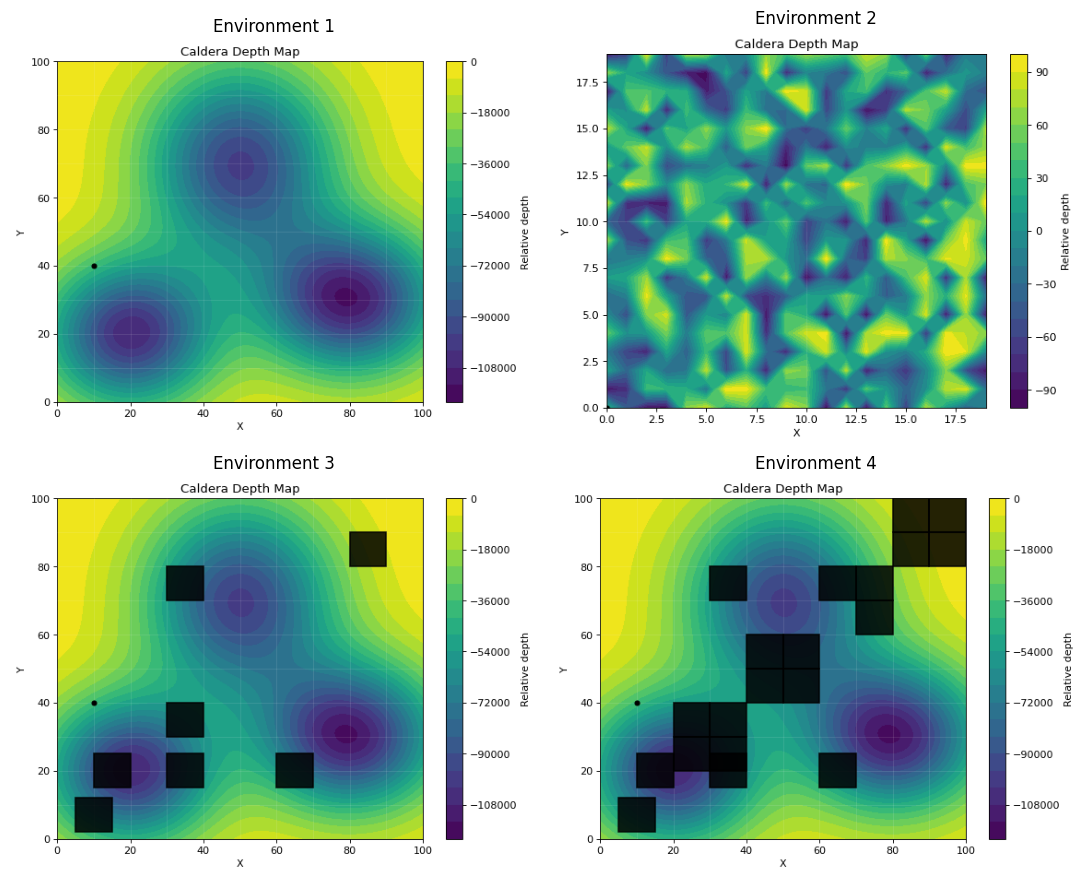

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, factory in zip(axes.flat, ENVIRONMENT_FACTORIES):
    env = factory()
    frame = render_env_frame(env, show_grid_lines=True)
    ax.imshow(frame)
    ax.set_title(env.id)
    ax.axis('off')
plt.tight_layout()
plt.show()

**Reminder:** We maintain a strict separation between the environment and the agent. Callbacks in `to_implement.py` do not receive the environment object; instead, each explorer receives a `task_info` dictionary containing only the information available to the agent. The helpers below construct this dictionary for each explorer type.


In [17]:
def al_task_info(env):
    return {
        'grid_dimensions': (env.dim_x, env.dim_y),
        'sampling_res': env.sampling_res,
        'initial_position': tuple(env.initial_position),
        'initial_energy': env.initial_energy,
    }



# Codebase

The codebase we provide separates the environment, agent wrappers, helper data structures, and the functions you will implement. 

As in HW2, we provide here the files you will use for implementing your agents. 
- `caldera_env.py` defines the Gymnasium-style Caldera environment. 
- `explorer.py` defines the explorer interfaces.
- `agent.py` defines the shared runner and the `step_info` / `episode_info` data schemas.
- `value_and_policy.py` provides simple `Policy` and `QTable` classes.
- `utils.py` contains shared helper functions for positions, bounds checking, paths, and terrain generation.

⚠️ The only code file that you will submit and that we will examine will be `to_implement.py`. Thus, your work should focus on this file, where you will complete the missing elements of the different agents.


# Task: ALExplorer - extending the active-learning explorer with learning capabilities


Your task is to find the deepest point in the Caldera while using a limited number of samples. In this stage, you can use learning to enhance the capabilities of your active-learning explorer. As a reminder, your explorer is not constrained by physical movement dynamics and can choose any grid location to sample according to its sampling budget and state of exploration, so the challenge is to identify informative samples.



For this task, you will implement active-learning callbacks that choose where the explorer samples next.

The candidate-selection function returns a list of valid sampling-grid `Position`s from the environment. The scoring function assigns a numeric score to a single candidate position.

The active-learning explorer scores these candidates and chooses the best one.


To make it easy to compare the approach you developed in HW2 with the learning-based approach developed here, we use four callbacks: two for the baseline active learner and two for the learning-based active learner.



```python
def select_candidate_queries_baseline(
    obs: dict,
    info: dict,
    candidate_set_size: int,
    task_info: dict,
) -> list[Position]:
    ...


def get_query_score_baseline(
    position: Position,
    obs: dict,
    info: dict,
    task_info: dict,
) -> float:
    ...


def select_candidate_queries_learning(
    obs: dict,
    info: dict,
    candidate_set_size: int,
    task_info: dict,
) -> list[Position]:
    ...


def get_query_score_learning(
    position: Position,
    obs: dict,
    info: dict,
    task_info: dict,
) -> float:
    ...
```


Note that each call to these functions should be efficient. Your agent will call them repeatedly during an episode, so you should balance informativeness with runtime cost. A good solution chooses a useful candidate set and scores those candidates quickly.


Note: **Persistent state across calls.** Each of these callbacks is invoked once per environment step, but the explorer does **not** pass any per-instance state to them; it passes only `obs`, `info`, `candidate_set_size`, and `task_info`. If your strategy needs to remember information across calls (for example, the active learner typically needs the history of positions it has already sampled and their values), use the module-level dictionary `to_implement.g_task_info` as persistent scratch space. Anything you write into `g_task_info` will still be there on the next call. You are responsible for detecting and resetting your state at the start of a new episode, for instance by checking that the current position equals `task_info["initial_position"]` and that the energy equals `task_info["initial_energy"]`.


The `task_info` component will include the following:


```python
task_info = {
    "grid_dimensions": (env.dim_x, env.dim_y),
    "sampling_res": env.sampling_res,
    "initial_position": tuple(env.initial_position),
    "initial_energy": env.initial_energy,
}
```


For this task, you may use functions from the Python standard library, NumPy, and PyTorch. PyTorch is useful if you choose to build a learned surrogate model for the active learner: for example, you can convert sampled `(x, y)` positions and depth values into tensors, train a small `torch.nn` model to predict depth from position, and use the model predictions to score unsampled candidate locations.

Keep the PyTorch component lightweight. The callbacks are called during an episode, so expensive training inside every decision step can make rollouts slow. Prefer caching sampled history, trained models, and reusable tensors in `g_task_info`; use `torch.no_grad()` during inference; and detach tensors before converting them back to NumPy or Python scalars. Your code should not assume that a GPU is available.


## Testing your implementation

### Sanity checks

These checks validate the contract of both active-learning callback pairs: baseline and learning. For each pair, candidates must be valid sampling-grid `Position`s, scores must be scalar floats, the sample budget must be respected, and the explorer's `samples_collected` counter must match the fresh samples actually taken.


In [18]:
test = unittest.TestCase()
np.random.seed(0)

CALLBACK_VARIANTS = {
    'baseline': (
        ti.select_candidate_queries_baseline,
        ti.get_query_score_baseline,
    ),
    'learning': (
        ti.select_candidate_queries_learning,
        ti.get_query_score_learning,
    ),
}

for variant_name, (select_candidate_queries_fn, get_query_score_fn) in CALLBACK_VARIANTS.items():
    np.random.seed(0)
    if hasattr(ti, 'g_task_info'):
        ti.g_task_info.clear()

    env = create_environment_1()
    task_info = al_task_info(env)
    initial_obs = {
        'position': np.array(env.initial_position),
        'value': np.array(np.inf),
        'sampled_before': 0,
        'energy': env.initial_energy,
        'max_value_observed': np.array(-np.inf),
        'min_value_observed': np.array(np.inf),
    }

    # 1) candidates are valid grid positions
    candidates = select_candidate_queries_fn(
        obs=initial_obs,
        info={},
        candidate_set_size=5,
        task_info=task_info,
    )
    test.assertEqual(len(candidates), 5, msg=f'{variant_name}: wrong number of candidates')
    for c in candidates:
        test.assertEqual(len(c), 2, msg=f'{variant_name}: candidate is not 2D')
        test.assertTrue(
            0 <= c[0] <= env.dim_x and 0 <= c[1] <= env.dim_y,
            msg=f'{variant_name}: candidate out of bounds: {c}',
        )
        test.assertEqual(c[0] % env.sampling_res, 0, msg=f'{variant_name}: invalid x-grid coordinate')
        test.assertEqual(c[1] % env.sampling_res, 0, msg=f'{variant_name}: invalid y-grid coordinate')

    # 2) scoring returns a real float
    score = get_query_score_fn(
        position=candidates[0], obs=initial_obs, info={}, task_info=task_info,
    )
    test.assertIsInstance(float(score), float, msg=f'{variant_name}: score is not numeric')

    # 3) sample budget is respected
    MAX_SAMPLES = 15
    al = ALExplorer(
        env=env, task_info=task_info,
        max_samples=MAX_SAMPLES, candidate_set_size=5,
        select_candidate_positions_fn=select_candidate_queries_fn,
        get_query_score_fn=get_query_score_fn,
    )
    episode_info = al.run_episode()
    test.assertLessEqual(al.samples_collected, MAX_SAMPLES, msg=f'{variant_name}: sample budget exceeded')
    test.assertGreater(al.samples_collected, 0, msg=f'{variant_name}: no samples collected')

    fresh_samples = [
        step for step in episode_info['trajectory']
        if step['action'] == SAMPLE and int(step['next_obs'].get('sampled_before', 1)) == 0
    ]
    test.assertEqual(
        al.samples_collected,
        len(fresh_samples),
        msg=f'{variant_name}: samples_collected does not match fresh samples',
    )

    # 4) best_value_observed is set and actually came from the depth field
    pos, val = al.get_best_value()
    test.assertIsNotNone(val, msg=f'{variant_name}: best value was not set')
    test.assertIsNotNone(pos, msg=f'{variant_name}: best position was not set')
    expected = env._get_value(pos)
    test.assertAlmostEqual(val, expected, places=3, msg=f'{variant_name}: best value mismatch')

    print(
        f'{variant_name} AL sanity checks passed. '
        f'samples_collected={al.samples_collected}, best={val:.1f} at {pos}'
    )


baseline AL sanity checks passed. samples_collected=15, best=-115702.0 at (80, 30)
learning AL sanity checks passed. samples_collected=15, best=-107346.3 at (20, 20)
